## Parcellation Yeo Networks

*This script was used to create  the figure in the Supplement that illustrates the seven Yeo networks.*

In [2]:
import sys
print(sys.version) #check which python version is used

3.10.16 | packaged by conda-forge | (main, Dec  5 2024, 14:07:43) [MSC v.1942 64 bit (AMD64)]


In [4]:
import os
import glob
from pathlib import Path

import numpy as np
from scipy.stats import rankdata, ttest_rel, ttest_1samp

from matplotlib import pyplot as plt
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms

import pandas as pd
import seaborn as sns

import nibabel as nib
from nilearn.input_data import NiftiLabelsMasker
from nilearn.plotting import plot_glass_brain, plot_stat_map, view_img, view_img_on_surf

from sklearn.metrics import pairwise_distances
from sklearn.utils import check_random_state
from sklearn.manifold import TSNE

%matplotlib inline

from nltools.data import Brain_Data, Adjacency
from nltools.mask import roi_to_brain, expand_mask
from nltools.stats import fdr, threshold

In [6]:
print(os.getcwd())
os.chdir("E:\Data Project 4")
print(os.getcwd())

C:\Users\jop86ib\Documents\Paper 4\Code\Test Stuff
E:\Data Project 4


### 1. Import Brain Masks

In [8]:
mask_yeo_17 = Brain_Data(r'E:\Data Project 4\200Parcels_Yeo2011_17Networks_FSLMNI152_2mm.nii.gz')
mask_yeo_7 = Brain_Data(r'E:\Data Project 4\200Parcels_Yeo2011_7Networks_FSLMNI152_2mm.nii.gz')

In [10]:
expand_mask(mask_yeo_17)
expand_mask(mask_yeo_7)

nltools.data.brain_data.Brain_Data(data=(200, 238955), Y=(0, 0), X=(0, 0), mask=MNI152_T1_2mm_brain_mask.nii.gz)

### 2. Define Nodes Belonging to the YEO 17 and the YEO 7 Networks

*Source: Github Thomas Yeo Lab: https://github.com/ThomasYeoLab/CBIG/tree/master/stable_projects/brain_parcellation/Yan2023_homotopic*

In [14]:
# Define Nodes belonging to YEO 17 (specific networks)

nodes_yeo_17_network_1_TempPar = [0,1,2,100,101,102,116]
nodes_yeo_17_network_2_DefaultC = [3,4,5,103,104,105]
nodes_yeo_17_network_3_DefaultB = [6,7,8,9,10,11,12,13,14,15,16,17,108,109,111,114,115]
nodes_yeo_17_network_4_DefaultA = [18,19,20,21,22,23,24,25,26,27,107,117,119,120,121,122,123,124,125,126,127]
nodes_yeo_17_network_5_ContC = [28,29,30,128,129,130]
nodes_yeo_17_network_6_ContB = [31,32,33,34,110,118,131,132,133,134]
nodes_yeo_17_network_7_ContA = [35,36,37,38,39,40,41,135,136,137,138,140,141,169]
nodes_yeo_17_network_8_LimbicA = [42,43,142,143]
nodes_yeo_17_network_9_LimbicB = [44,45,46,144,145,146]
nodes_yeo_17_network_10_SalVent_AttnB = [47,48,49,50,106,112,113,139,147,148,149,150]
nodes_yeo_17_network_11_SalVent_AttnA = [51,52,53,54,55,56,151,152,153,154,155,156,178]
nodes_yeo_17_network_12_DorsAttnB = [57,58,59,60,61,62,157,158,159,160,161,162]
nodes_yeo_17_network_13_DorsAttnA = [63,64,65,66,67,68,69,163,164,165,166,167,168]
nodes_yeo_17_network_14_SomMotB = [70,71,72,73,74,75,76,77,78,170,171,172,173,174,175,176,177]
nodes_yeo_17_network_15_SomMotA = [79,80,81,82,83,84,85,86,87,88,179,180,181,182,183,184,185,186,187,188]
nodes_yeo_17_network_16_VisPeri = [89,90,91,92,189,190,191,192]
nodes_yeo_17_network_17_VisCent = [93,94,95,96,97,98,99,193,194,195,196,197,198,199]

In [16]:
# Define Nodes belonging to YEO 7 (specific networks)

nodes_yeo_7_network_1_Default = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,100,101,102,104,106,107,108,109,110,113,114,115,116,117,121,122,123,124,125,128]
nodes_yeo_7_network_2_Cont = [30,31,32,33,34,35,36,37,38,39,103,105,111,112,119,120,129,130,131,132,133,135,136,137,138]
nodes_yeo_7_network_3_Limbic = [40,41,42,43,44,140,141,142,143,144]
nodes_yeo_7_network_4_SalVentAttn = [45,46,47,48,49,50,51,52,53,54,118,126,145,146,147,148,149,150,151,152,153,154]
nodes_yeo_7_network_5_DorsAttn = [55,56,57,58,59,60,61,62,63,64,65,66,67,68,134,139,155,156,157,158,159,160,161,162,163,164,165,166,167,168,199]
nodes_yeo_7_network_6_SomMot = [69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,127,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186]
nodes_yeo_7_network_7_Vis = [87,88,89,90,91,92,93,94,95,96,97,98,99,187,188,189,190,191,192,193,194,195,196,197,198]

### 3. Define Node Names

In [18]:
node_names_yeo_17 = ['LH_TempPar_Temp_1',
              'LH_TempPar_Temp_2',
              'LH_TempPar_Temp_3',
              'LH_DefaultC_IPL',
              'LH_DefaultC_PHC',
              'LH_DefaultC_RSC',
              'LH_DefaultB_IPL_1',
              'LH_DefaultB_IPL_2',
              'LH_DefaultB_PFCd_1', 
              'LH_DefaultB_PFCd_2', 
              'LH_DefaultB_PFCl',
              'LH_DefaultB_PFCv_1', 
              'LH_DefaultB_PFCv_2', 
              'LH_DefaultB_PFCv_3',
              'LH_DefaultB_TempPole', 
              'LH_DefaultB_Temp_1', 
              'LH_DefaultB_Temp_2', 
              'LH_DefaultB_Temp_3', 
              'LH_DefaultA_IPL_1',
              'LH_DefaultA_PCC', 
              'LH_DefaultA_PFCd_1', 
              'LH_DefaultA_PFCd_2',
              'LH_DefaultA_PFCd_3', 
              'LH_DefaultA_PFCm_1', 
              'LH_DefaultA_PFCm_2',
              'LH_DefaultA_PFCm_3', 
              'LH_DefaultA_PFCm_4', 
              'LH_DefaultA_pCun',
              'LH_ContC_PCC', 
              'LH_ContC_pCun_1',
              'LH_ContC_pCun_2',
              'LH_ContB_FPole',
              'LH_ContB_IPL_1', 
              'LH_ContB_PFCv', 
              'LH_ContB_Temp',
              'LH_ContA_IPS_1',
              'LH_ContA_IPS_2', 
              'LH_ContA_PFCd',
              'LH_ContA_PFCl_1',
              'LH_ContA_PFCl_2', 
              'LH_ContA_PrCv_1',
              'LH_ContA_PrCv_2',
              'LH_LimbicA_Temp',
              'LH_LimbicA_TempPole',
              'LH_LimbicB_FPole',
              'LH_LimbicB_OFC_1',
              'LH_LimbicB_OFC_2',
              'LH_SalVentAttnB_FrMed_1',
              'LH_SalVentAttnB_FrMed_2',
              'LH_SalVentAttnB_PFCl_1', 
              'LH_SalVentAttnB_PFCl_2',
              'LH_SalVentAttnA_FrMed_1',
              'LH_SalVentAttnA_FrMed_2',
              'LH_SalVentAttnA_IPL', 
              'LH_SalVentAttnA_Ins_1',
              'LH_SalVentAttnA_Ins_2', 
              'LH_SalVentAttnA_SPL', 
              'LH_DorsAttnB_PostC_1',
              'LH_DorsAttnB_PostC_2',
              'LH_DorsAttnB_PrCd_1',
              'LH_DorsAttnB_PrCd_2',
              'LH_DorsAttnB_SPL_1',
              'LH_DorsAttnB_SPL_2', 
              'LH_DorsAttnA_IPS',
              'LH_DorsAttnA_SPL_1',
              'LH_DorsAttnA_SPL_2',
              'LH_DorsAttnA_TempOcc_1',
              'LH_DorsAttnA_TempOcc_2',
              'LH_DorsAttnA_TempOcc_3',
              'LH_DorsAttnA_TempOcc_4',
              'LH_SomMotB_1',
              'LH_SomMotB_2',
              'LH_SomMotB_3',
              'LH_SomMotB_4',
              'LH_SomMotB_Ins_1',
              'LH_SomMotB_Ins_2',
              'LH_SomMotB_Ins_3',
              'LH_SomMotB_ST_1',
              'LH_SomMotB_ST_2',
              'LH_SomMotA_1',
              'LH_SomMotA_10',
              'LH_SomMotA_2',
              'LH_SomMotA_3',
              'LH_SomMotA_4',
              'LH_SomMotA_5',
              'LH_SomMotA_6',
              'LH_SomMotA_7',
              'LH_SomMotA_8',
              'LH_SomMotA_9',
              'LH_VisPeri_ExStrInf_1',
              'LH_VisPeri_ExStrInf_2',
              'LH_VisPeri_ExStrSup',
              'LH_VisPeri_Striate',
              'LH_VisCent_ExStr_1',
              'LH_VisCent_ExStr_2',
              'LH_VisCent_ExStr_3',
              'LH_VisCent_ExStr_4',
              'LH_VisCent_ExStr_5',
              'LH_VisCent_ExStr_6',
              'LH_VisCent_Striate',
              'RH_TempPar_Temp_1',
              'RH_TempPar_Temp_2',
              'RH_TempPar_Temp_3',
              'RH_DefaultC_IPL',
              'RH_DefaultC_PHC',
              'RH_DefaultC_RSC',
              'RH_SalVentAttnB_IPL',
              'RH_DefaultA_IPL_1',
              'RH_DefaultB_PFCd_1',
              'RH_DefaultB_PFCd_2',
              'RH_ContB_PFCl',
              'RH_DefaultB_PFCv_1',
              'RH_SalVentAttnB_PFCv_1',
              'RH_SalVentAttnB_PFCv_2',
              'RH_DefaultB_TempPole',
              'RH_DefaultB_Temp_1',
              'RH_TempPar_Temp_4',
              'RH_DefaultA_Temp',
              'RH_ContB_IPL_2',
              'RH_DefaultA_PCC',
              'RH_DefaultA_PFCd_1',
              'RH_DefaultA_PFCd_2',
              'RH_DefaultA_PFCd_3',
              'RH_DefaultA_PFCm_1',
              'RH_DefaultA_PFCm_2',
              'RH_DefaultA_PFCm_3',
              'RH_DefaultA_PFCm_4',
              'RH_DefaultA_pCun',
              'RH_ContC_PCC',
              'RH_ContC_pCun_1',
              'RH_ContC_pCun_2',
              'RH_ContB_FPole',
              'RH_ContB_IPL_1',
              'RH_ContB_PFCv',
              'RH_ContB_Temp',
              'RH_ContA_IPS_1',
              'RH_ContA_IPS_2',
              'RH_ContA_PFCd',
              'RH_ContA_PFCl_1',
              'RH_SalVentAttnB_PFCl_3',
              'RH_ContA_PrCv_1',
              'RH_ContA_PrCv_2',
              'RH_LimbicA_Temp',
              'RH_LimbicA_TempPole',
              'RH_LimbicB_FPole',
              'RH_LimbicB_OFC_1',
              'RH_LimbicB_OFC_2',
              'RH_SalVentAttnB_FrMed_1',
              'RH_SalVentAttnB_FrMed_2',
              'RH_SalVentAttnB_PFCl_1',
              'RH_SalVentAttnB_PFCl_2',
              'RH_SalVentAttnA_FrMed_1',
              'RH_SalVentAttnA_FrMed_2',
              'RH_SalVentAttnA_IPL',
              'RH_SalVentAttnA_Ins_1',
              'RH_SalVentAttnA_Ins_2',
              'RH_SalVentAttnA_SPL',
              'RH_DorsAttnB_PostC_1',
              'RH_DorsAttnB_PostC_2',
              'RH_DorsAttnB_PrCd_1',
              'RH_DorsAttnB_PrCd_2',
              'RH_DorsAttnB_SPL_1',
              'RH_DorsAttnB_SPL_2',
              'RH_DorsAttnA_IPS',
              'RH_DorsAttnA_SPL_1',
              'RH_DorsAttnA_SPL_2',
              'RH_DorsAttnA_TempOcc_1',
              'RH_DorsAttnA_TempOcc_2',
              'RH_DorsAttnA_TempOcc_3',
              'RH_ContA_TempOcc',
              'RH_SomMotB_1',
              'RH_SomMotB_2',
              'RH_SomMotB_3',
              'RH_SomMotB_4',
              'RH_SomMotB_Ins_1',
              'RH_SomMotB_Ins_2',
              'RH_SomMotB_Ins_3',
              'RH_SomMotB_ST_1',
              'RH_SalVentAttnA_ST',
              'RH_SomMotA_1',
              'RH_SomMotA_10',
              'RH_SomMotA_2',
              'RH_SomMotA_3',
              'RH_SomMotA_4',
              'RH_SomMotA_5',
              'RH_SomMotA_6',
              'RH_SomMotA_7',
              'RH_SomMotA_8',
              'RH_SomMotA_9',
              'RH_VisPeri_ExStrInf_1',
              'RH_VisPeri_ExStrInf_2',
              'RH_VisPeri_ExStrSup',
              'RH_VisPeri_Striate',
              'RH_VisCent_ExStr_1',
              'RH_VisCent_ExStr_2',
              'RH_VisCent_ExStr_3',
              'RH_VisCent_ExStr_4',
              'RH_VisCent_ExStr_5',
              'RH_VisCent_ExStr_6',
              'RH_VisCent_Striate']

In [ ]:
node_names_yeo_7 = ['LH_Default_IPL_1',
                    'LH_Default_IPL_2',
                    'LH_Default_IPL_3',
                    'LH_Default_IPL_4',
                    'LH_Default_PCC_1',
                    'LH_Default_PCC_2',
                    'LH_Default_PFCd_1',
                    'LH_Default_PFCd_2',
                    'LH_Default_PFCd_3',
                    'LH_Default_PFCd_4',
                    'LH_Default_PFCd_5',
                    'LH_Default_PFCl_1',
                    'LH_Default_PFCl_2',
                    'LH_Default_PFCm_1',
                    'LH_Default_PFCm_2',
                    'LH_Default_PFCm_3',
                    'LH_Default_PFCm_4',
                    'LH_Default_PFCv_1',
                    'LH_Default_PFCv_2',
                    'LH_Default_PFCv_3',
                    'LH_Default_PFCv_4',
                    'LH_Default_RSC',
                    'LH_Default_TempPole',
                    'LH_Default_Temp_1',
                    'LH_Default_Temp_2',
                    'LH_Default_Temp_3',
                    'LH_Default_Temp_4',
                    'LH_Default_Temp_5',
                    'LH_Default_pCun_1',
                    'LH_Default_pCun_2',
                    'LH_Cont_FPole',
                    'LH_Cont_FrMed',
                    'LH_Cont_IPL_1',
                    'LH_Cont_IPS_1',
                    'LH_Cont_IPS_2',
                    'LH_Cont_PFCl_1',
                    'LH_Cont_PFCl_2',
                    'LH_Cont_PFCl_3',
                    'LH_Cont_Temp',
                    'LH_Cont_pCun_1',
                    'LH_Limbic_FPole',
                    'LH_Limbic_OFC_1',
                    'LH_Limbic_OFC_2',
                    'LH_Limbic_Temp',
                    'LH_Limbic_TempPole',
                    'LH_SalVentAttn_FrMed_1',
                    'LH_SalVentAttn_FrMed_2',
                    'LH_SalVentAttn_FrMed_3',
                    'LH_SalVentAttn_IPL',
                    'LH_SalVentAttn_Ins_1',
                    'LH_SalVentAttn_Ins_2',
                    'LH_SalVentAttn_PrCv',
                    'LH_SalVentAttn_SPL',
                    'LH_SalVentAttn_ST',
                    'LH_SalVentAttn_Temp_1',
                    'LH_DorsAttn_IPS_1',
                    'LH_DorsAttn_PFCd',
                    'LH_DorsAttn_PostC_1',
                    'LH_DorsAttn_PostC_2',
                    'LH_DorsAttn_PrCd_1',
                    'LH_DorsAttn_PrCd_2',
                    'LH_DorsAttn_PrCv',
                    'LH_DorsAttn_SPL_1',
                    'LH_DorsAttn_SPL_2',
                    'LH_DorsAttn_SPL_3',
                    'LH_DorsAttn_SPL_4',
                    'LH_DorsAttn_TempOcc_1',
                    'LH_DorsAttn_TempOcc_2',
                    'LH_DorsAttn_TempOcc_3',
                    'LH_SomMot_1',
                    'LH_SomMot_10',
                    'LH_SomMot_11',
                    'LH_SomMot_12',
                    'LH_SomMot_13',
                    'LH_SomMot_14',
                    'LH_SomMot_2',
                    'LH_SomMot_3',
                    'LH_SomMot_4',
                    'LH_SomMot_5',
                    'LH_SomMot_6',
                    'LH_SomMot_7',
                    'LH_SomMot_8',
                    'LH_SomMot_9',
                    'LH_SomMot_Ins_1',
                    'LH_SomMot_Ins_2',
                    'LH_SomMot_Ins_3',
                    'LH_SomMot_ST',
                    'LH_Vis_ExStrInf_1',
                    'LH_Vis_ExStrInf_2',
                    'LH_Vis_ExStrSup',
                    'LH_Vis_ExStr_1',
                    'LH_Vis_ExStr_2',
                    'LH_Vis_ExStr_3',
                    'LH_Vis_ExStr_4',
                    'LH_Vis_ExStr_5',
                    'LH_Vis_ExStr_6',
                    'LH_Vis_PHC',
                    'LH_Vis_Striate_1',
                    'LH_Vis_Striate_2',
                    'LH_Vis_TempOcc',
                    'RH_Default_IPL_1',
                    'RH_Default_IPL_2',
                    'RH_Default_IPL_3',
                    'RH_Cont_IPL_2',
                    'RH_Default_PCC_1',
                    'RH_Cont_PCC',
                    'RH_Default_PFCd_1',
                    'RH_Default_PFCd_2',
                    'RH_Default_PFCd_3',
                    'RH_Default_PFCd_4',
                    'RH_Default_PFCd_5',
                    'RH_Cont_PFCl_4',
                    'RH_Cont_PFCl_5',
                    'RH_Default_PFCm_1',
                    'RH_Default_PFCm_2',
                    'RH_Default_PFCm_3',
                    'RH_Default_PFCm_4',
                    'RH_Default_PFCv_1',
                    'RH_SalVentAttn_PFCv',
                    'RH_Cont_PFCv_1',
                    'RH_Cont_PFCv_2',
                    'RH_Default_RSC',
                    'RH_Default_TempPole',
                    'RH_Default_Temp_1',
                    'RH_Default_Temp_2',
                    'RH_Default_Temp_3',
                    'RH_SalVentAttn_Temp_2',
                    'RH_SomMot_Temp',
                    'RH_Default_pCun_1',
                    'RH_Cont_pCun_1',
                    'RH_Cont_FPole',
                    'RH_Cont_FrMed',
                    'RH_Cont_IPL_1',
                    'RH_Cont_IPS_1',
                    'RH_DorsAttn_IPS_2',
                    'RH_Cont_PFCl_1',
                    'RH_Cont_PFCl_2',
                    'RH_Cont_PFCl_3',
                    'RH_Cont_Temp',
                    'RH_DorsAttn_pCun',
                    'RH_Limbic_FPole',
                    'RH_Limbic_OFC_1',
                    'RH_Limbic_OFC_2',
                    'RH_Limbic_Temp',
                    'RH_Limbic_TempPole',
                    'RH_SalVentAttn_FrMed_1',
                    'RH_SalVentAttn_FrMed_2',
                    'RH_SalVentAttn_FrMed_3',
                    'RH_SalVentAttn_IPL',
                    'RH_SalVentAttn_Ins_1',
                    'RH_SalVentAttn_Ins_2',
                    'RH_SalVentAttn_PrCv',
                    'RH_SalVentAttn_SPL',
                    'RH_SalVentAttn_ST',
                    'RH_SalVentAttn_Temp_1',
                    'RH_DorsAttn_IPS_1',
                    'RH_DorsAttn_PFCd',
                    'RH_DorsAttn_PostC_1',
                    'RH_DorsAttn_PostC_2',
                    'RH_DorsAttn_PrCd_1',
                    'RH_DorsAttn_PrCd_2',
                    'RH_DorsAttn_PrCv',
                    'RH_DorsAttn_SPL_1',
                    'RH_DorsAttn_SPL_2',
                    'RH_DorsAttn_SPL_3',
                    'RH_DorsAttn_SPL_4',
                    'RH_DorsAttn_TempOcc_1',
                    'RH_DorsAttn_TempOcc_2',
                    'RH_DorsAttn_TempOcc_3',
                    'RH_SomMot_1',
                    'RH_SomMot_10',
                    'RH_SomMot_11',
                    'RH_SomMot_12',
                    'RH_SomMot_13',
                    'RH_SomMot_14',
                    'RH_SomMot_2',
                    'RH_SomMot_3',
                    'RH_SomMot_4',
                    'RH_SomMot_5',
                    'RH_SomMot_6',
                    'RH_SomMot_7',
                    'RH_SomMot_8',
                    'RH_SomMot_9',
                    'RH_SomMot_Ins_1',
                    'RH_SomMot_Ins_2',
                    'RH_SomMot_Ins_3',
                    'RH_SomMot_ST',
                    'RH_Vis_ExStrInf_1',
                    'RH_Vis_ExStrInf_2',
                    'RH_Vis_ExStrSup',
                    'RH_Vis_ExStr_1',
                    'RH_Vis_ExStr_2',
                    'RH_Vis_ExStr_3',
                    'RH_Vis_ExStr_4',
                    'RH_Vis_ExStr_5',
                    'RH_Vis_ExStr_6',
                    'RH_Vis_PHC',
                    'RH_Vis_Striate_1',
                    'RH_Vis_Striate_2',
                    'RH_DorsAttn_TempOcc']


In [ ]:
print(len(node_names_yeo_17))
print(len(node_names_yeo_7))

In [ ]:
node_name_yeo_17_dict = {i: name for i, name in enumerate(node_names_yeo_17)}
#print(node_name_dict)

In [ ]:
node_name_yeo_7_dict = {i: name for i, name in enumerate(node_names_yeo_7)}
#print(node_name_dict)

### 4. Plot the distinct networks

#### 4.1. 17 Yeo Networks

Plot für TempPar gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Test\Parcellations\TempPar_plot.png
Plot für DefaultC gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Test\Parcellations\DefaultC_plot.png
Plot für DefaultB gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Test\Parcellations\DefaultB_plot.png
Plot für DefaultA gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Test\Parcellations\DefaultA_plot.png
Plot für ContC gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Test\Parcellations\ContC_plot.png
Plot für ContB gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Test\Parcellations\ContB_plot.png
Plot für ContA gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Test\Parcellations\ContA_plot.png
Plot für LimbicA gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Test\Parcellations\LimbicA_plot.png
Plot für LimbicB gespeichert u

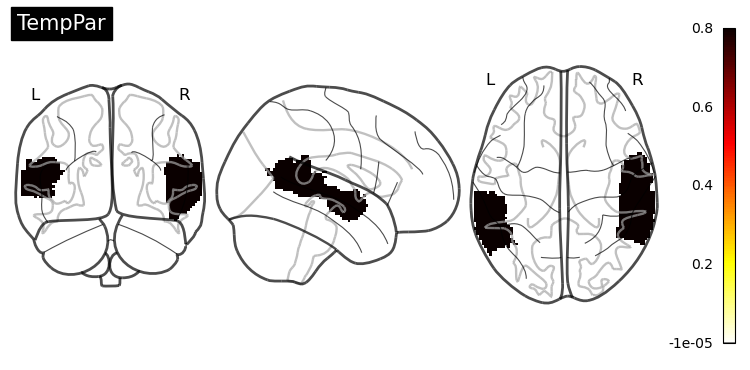

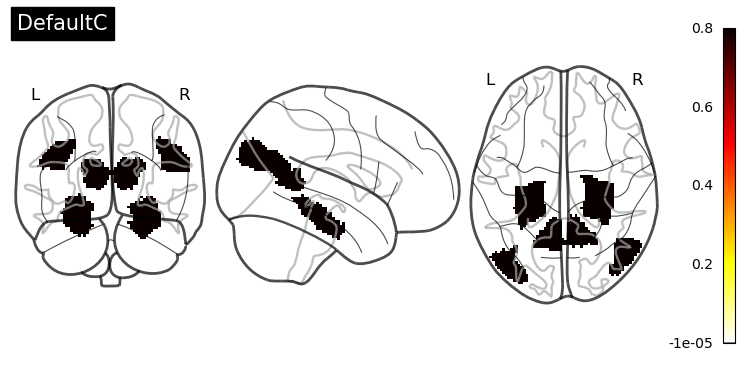

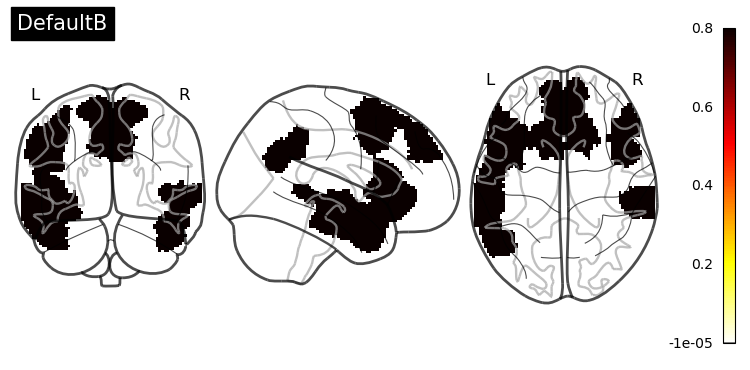

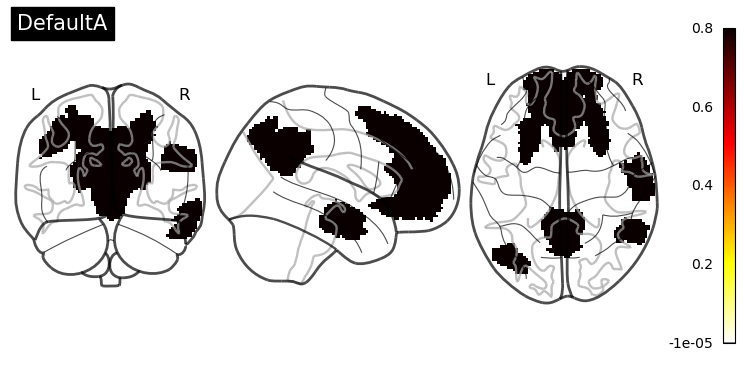

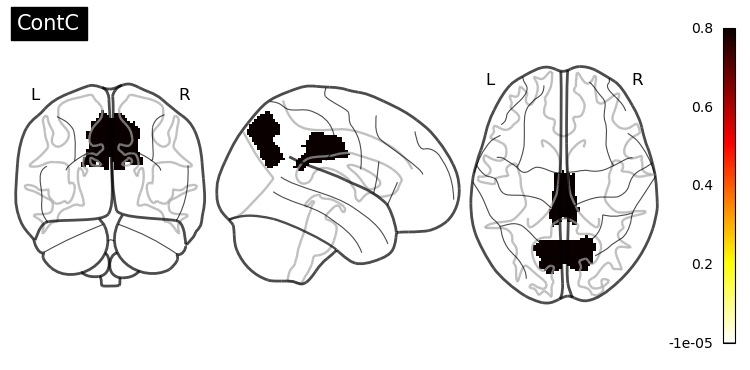

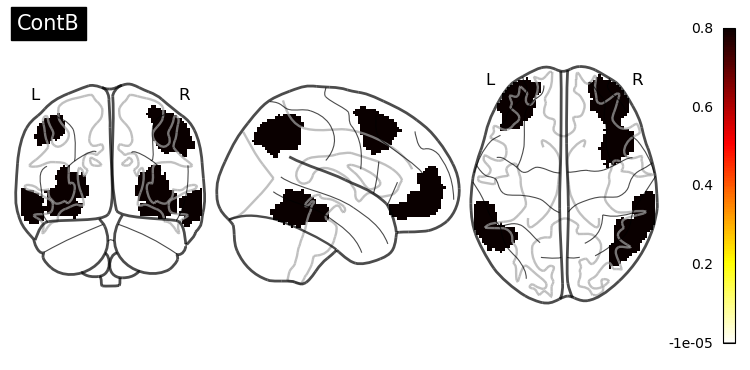

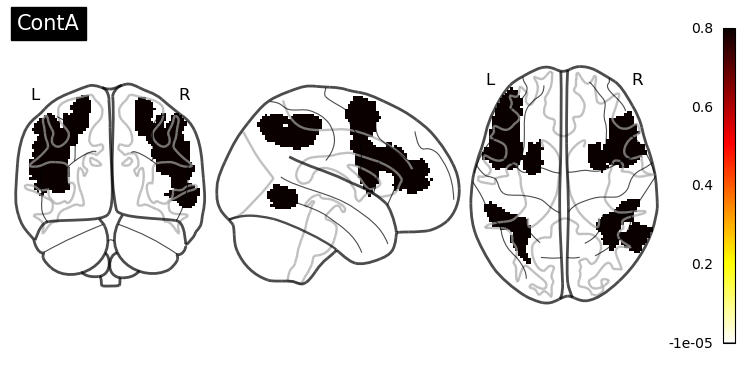

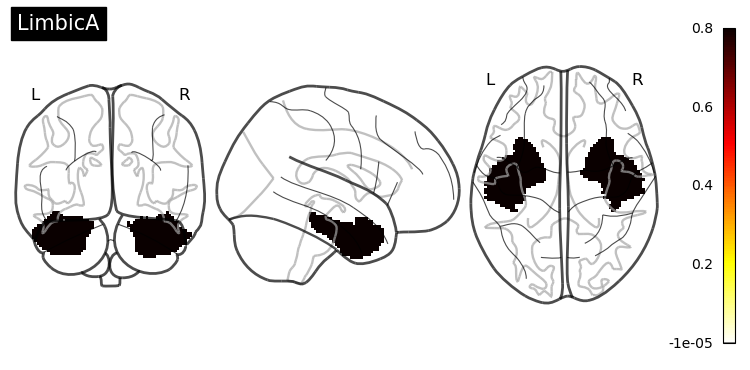

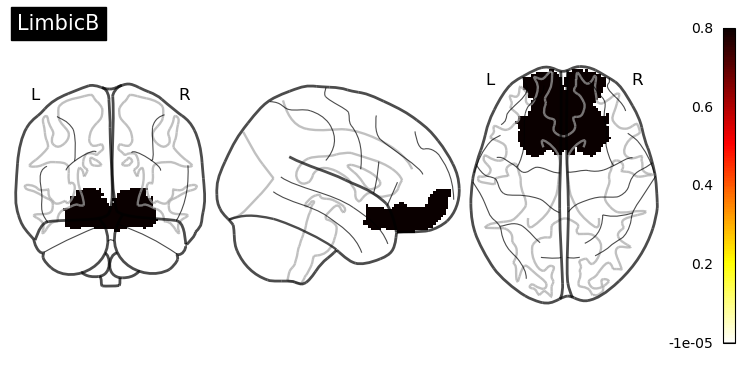

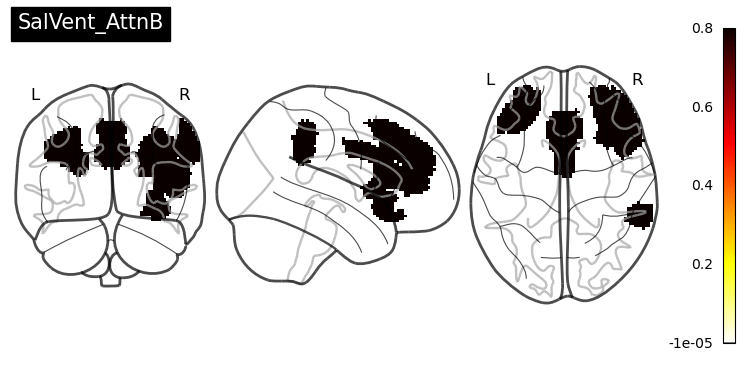

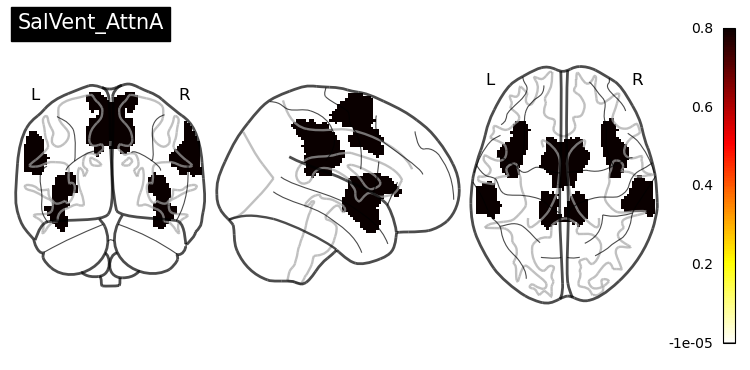

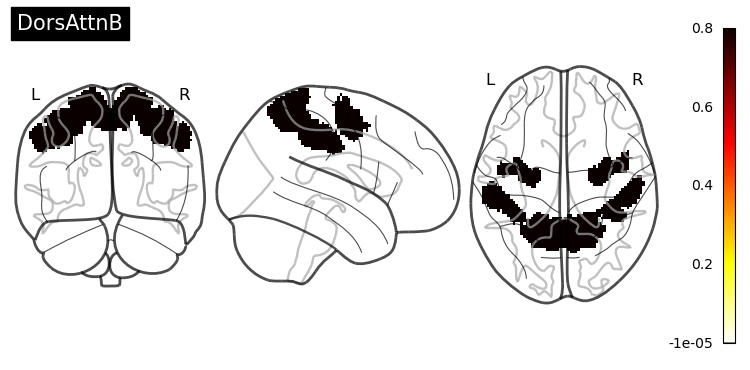

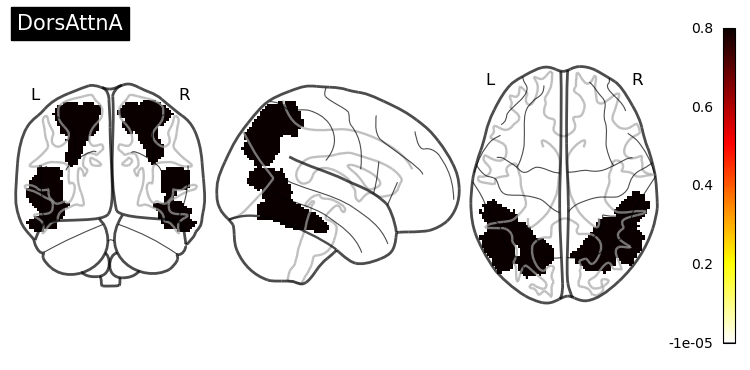

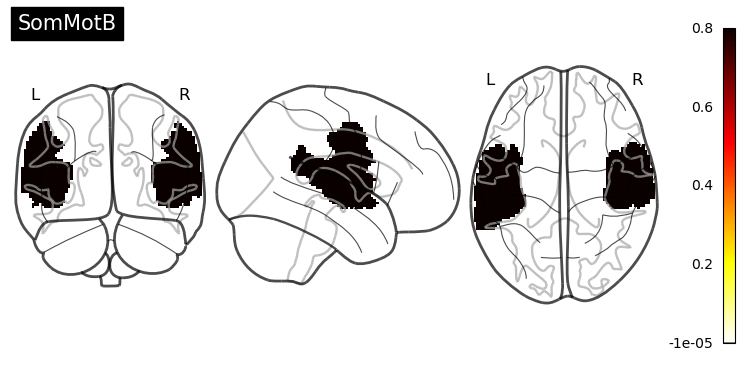

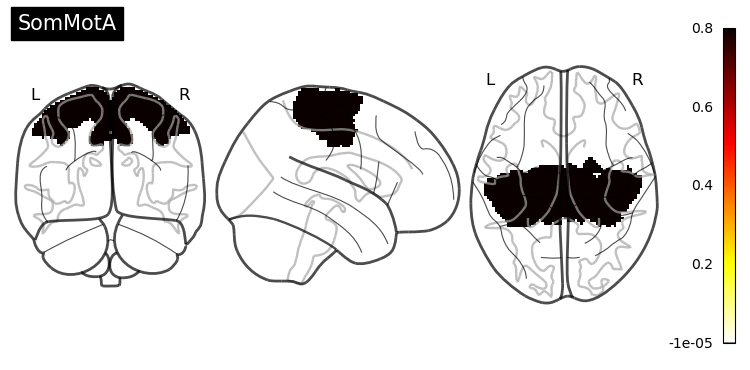

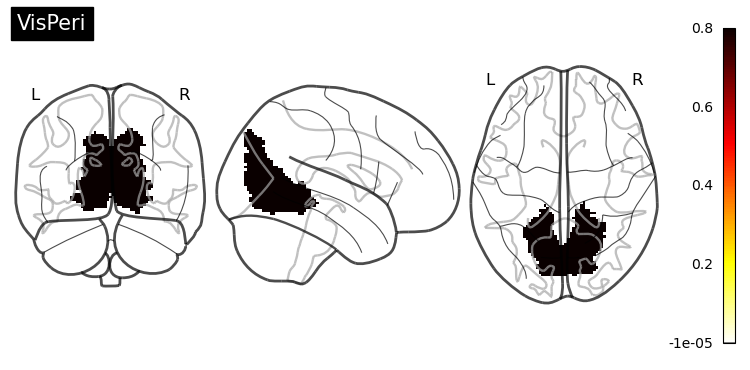

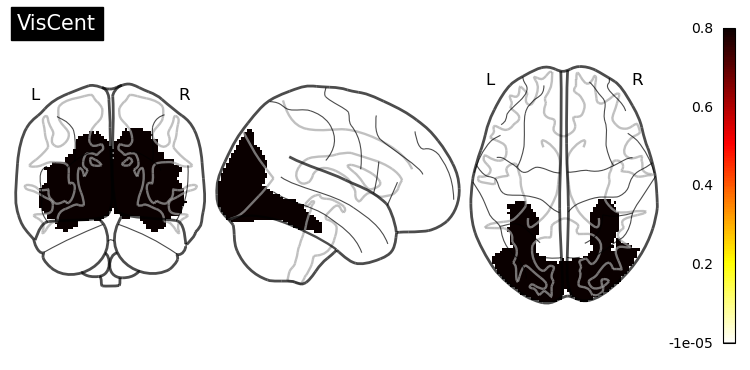

In [41]:
import numpy as np
import pandas as pd
from nilearn.plotting import plot_glass_brain
from nilearn.image import new_img_like

# Create folder to save the plots
file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Test\Parcellations"
os.makedirs(file_path_figure, exist_ok=True)

# Define networks and nodes
networks = {
    'TempPar': nodes_yeo_17_network_1_TempPar,
    'DefaultC': nodes_yeo_17_network_2_DefaultC,
    'DefaultB': nodes_yeo_17_network_3_DefaultB,
    'DefaultA': nodes_yeo_17_network_4_DefaultA,
    'ContC': nodes_yeo_17_network_5_ContC,
    'ContB': nodes_yeo_17_network_6_ContB,
    'ContA': nodes_yeo_17_network_7_ContA,
    'LimbicA': nodes_yeo_17_network_8_LimbicA,
    'LimbicB': nodes_yeo_17_network_9_LimbicB,
    'SalVent_AttnB': nodes_yeo_17_network_10_SalVent_AttnB,
    'SalVent_AttnA': nodes_yeo_17_network_11_SalVent_AttnA,
    'DorsAttnB': nodes_yeo_17_network_12_DorsAttnB,
    'DorsAttnA': nodes_yeo_17_network_13_DorsAttnA,
    'SomMotB': nodes_yeo_17_network_14_SomMotB,
    'SomMotA': nodes_yeo_17_network_15_SomMotA,
    'VisPeri': nodes_yeo_17_network_16_VisPeri,
    'VisCent': nodes_yeo_17_network_17_VisCent
}

# Define colors for each network
colors = [
    'red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 
    'pink', 'brown', 'gray', 'lime', 'teal', 'navy', 'gold', 'violet', 'indigo'
]

# Prepare data 
n_nodes = 200  # Maximum number of nodes
network_data = np.zeros(n_nodes)

#  Create one plot mask for each network
plot_data = {}
for idx, (network_name, nodes) in enumerate(networks.items()):
    mask = np.zeros(n_nodes)
    mask[nodes] = 0.8  # Value so that each node in the network is marked
    plot_data[network_name] = mask

# Create brain plot with all networks
for idx, (network_name, mask) in enumerate(plot_data.items()):
    network_brain = roi_to_brain(pd.Series(mask), expand_mask(mask_yeo_17))
    # Plot with correct color for each network 
    fig = plot_glass_brain(network_brain.to_nifti(), title=network_name, colorbar=True, display_mode='ortho', draw_cross=True)


    # Save Figure
    output_path = os.path.join(file_path_figure, f"{network_name}_plot.png")
    fig.savefig(output_path)
    print(f"Plot for {network_name} saved under {output_path}")

#### 4.2. 7 Yeo Networks

Plot für Default gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Parcellations\Default_plot.png
Plot für Cont gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Parcellations\Cont_plot.png
Plot für Limbic gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Parcellations\Limbic_plot.png
Plot für SalVentAttn gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Parcellations\SalVentAttn_plot.png
Plot für DorsAttn gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Parcellations\DorsAttn_plot.png
Plot für SomMot gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Parcellations\SomMot_plot.png
Plot für Vis gespeichert unter C:\Users\jop86ib\Documents\Paper 4\Results\Figures\Parcellations\Vis_plot.png


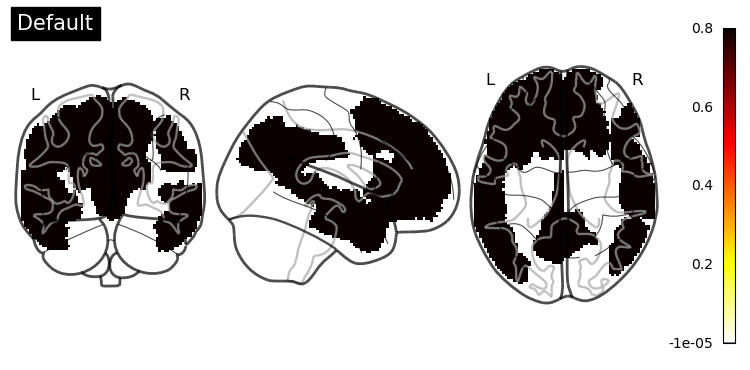

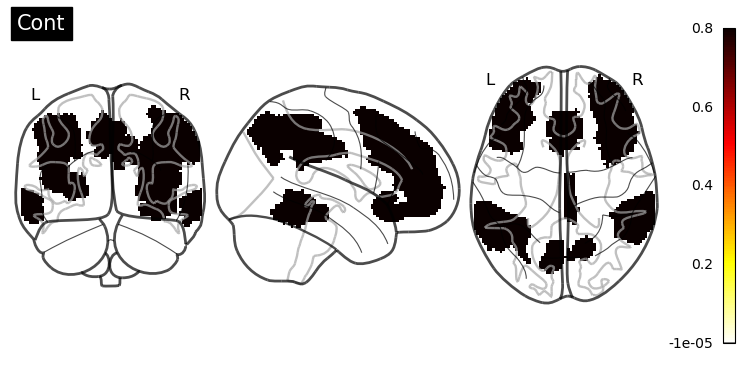

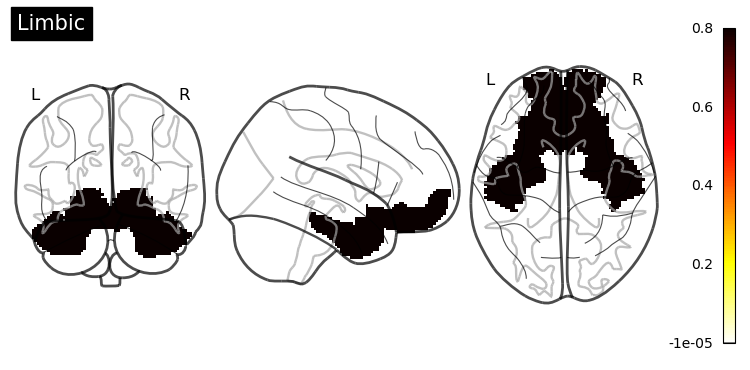

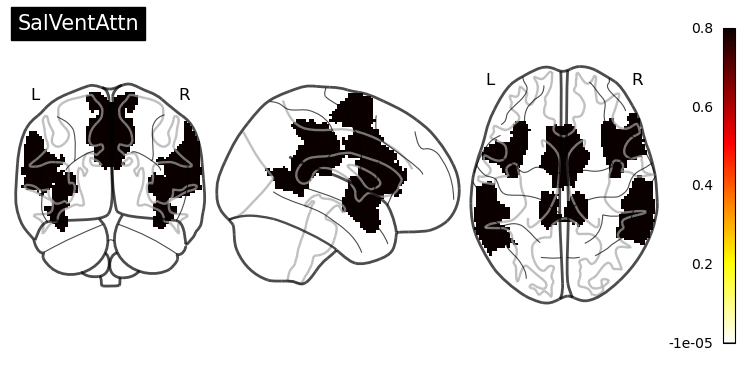

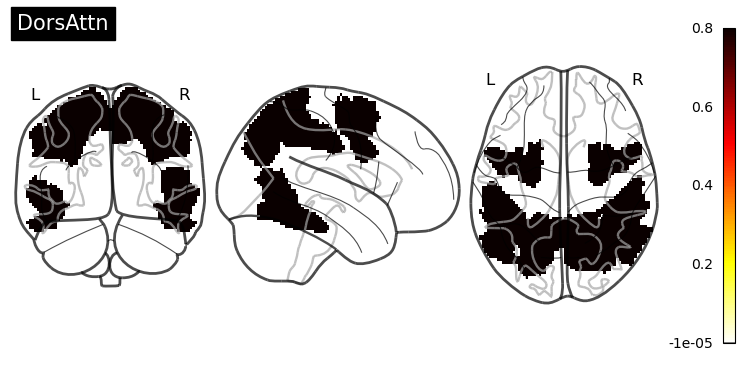

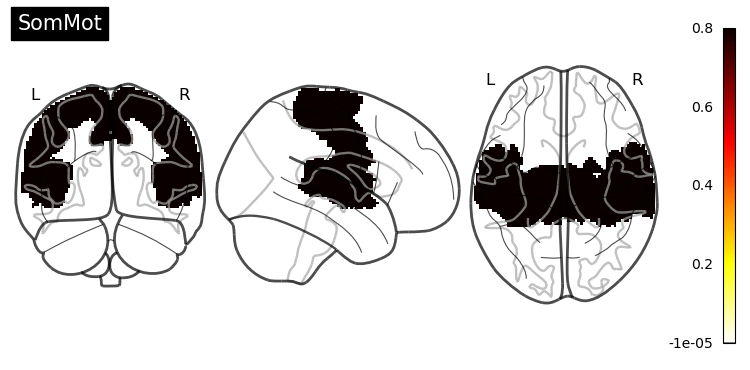

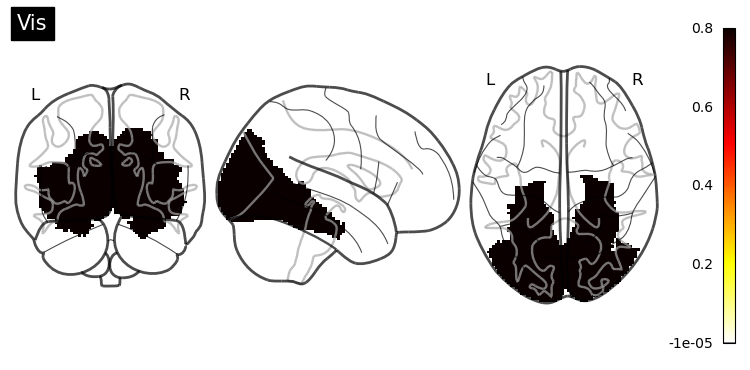

In [45]:
import numpy as np
import pandas as pd
from nilearn.plotting import plot_glass_brain
from nilearn.image import new_img_like

# Create folder to save the plots 
file_path_figure = r"C:\Users\jop86ib\Documents\Paper 4\Results\Test\Parcellations"
os.makedirs(file_path_figure, exist_ok=True)

# Define networks and nodes 
networks = {
    'Default': nodes_yeo_7_network_1_Default,
    'Cont': nodes_yeo_7_network_2_Cont,
    'Limbic': nodes_yeo_7_network_3_Limbic,
    'SalVentAttn': nodes_yeo_7_network_4_SalVentAttn,
    'DorsAttn': nodes_yeo_7_network_5_DorsAttn,
    'SomMot': nodes_yeo_7_network_6_SomMot,
    'Vis': nodes_yeo_7_network_7_Vis
}

# Define colors for each network 
colors = [
    'red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 
    'pink', 'brown', 'gray', 'lime', 'teal', 'navy', 'gold', 'violet', 'indigo'
]

# Prepare data
n_nodes = 200  # Mmaximum number of nodes
network_data = np.zeros(n_nodes)

#  Create plot-mask for each network 
plot_data = {}
for idx, (network_name, nodes) in enumerate(networks.items()):
    mask = np.zeros(n_nodes)
    mask[nodes] = 0.8  # Value so that each node in the network is marked
    plot_data[network_name] = mask

# Create brain plot with all networks
for idx, (network_name, mask) in enumerate(plot_data.items()):
    network_brain = roi_to_brain(pd.Series(mask), expand_mask(mask_yeo_7))
    # Plot with correct color fore each network
    fig = plot_glass_brain(network_brain.to_nifti(), title=network_name, colorbar=True, display_mode='ortho', draw_cross=True)


    # Save figure
    output_path = os.path.join(file_path_figure, f"{network_name}_plot.png")
    fig.savefig(output_path)
    print(f"Plot for {network_name} saved under {output_path}")